###Μηχανική Μάθηση
####1η ατομική εργασία
ΣΗΜΜΥ- ΕΜΠ -Ακ. Έτος 2025-26



# ⚠️
`Επισημαίνεται ότι απαγορεύεται η ανάρτηση των λύσεων των εργαστηριακών ασκήσεων στο github, ή σε άλλες ιστοσελίδες. Η σχεδίαση και το περιεχόμενο των εργαστηριακών projects αποτελούν αντικείμενο πνευματικής ιδιοκτησίας της διδακτικής ομάδας του μαθήματος.`

 `⚠️  Το σύνολο δεδομένων που σας δόθηκε δεν πρέπει να εμπλουτισθεί με οποιοδήποτε τρόπο. Η εργασία στην οποία θα χρησιμοποιηθεί εμπλουτισμένο σύνολο δεδομένων, δεν θα διορθωθεί.`

Ονοματεπώνυμο φοιτητή: Γεώργιος Κωνσταντόπουλος

Α.Μ.: 03122104

### 1. Εισαγωγή συνόλου δεδομένων

Tο σύνολο δεδομένων για το training-validation μπορείτε να το κατεβάσετε από [εδώ](https://drive.google.com/file/d/1PRxhsDEF6em2Ut095c790CbBmuDdSgr5/view?usp=sharing).


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1.α. Φορτώστε το σύνολο δεδομένων "train-val.csv"  στο notebook σας.

In [52]:
df=pd.read_csv('train-val.csv')
display(df.head())

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2009-03-22,Albury,14.6,30.0,0.0,NaN,NaN,NE,37.0,E,...,56.0,30.0,1014.8,1012.7,3.0,1.0,18.1,29.0,No,No
1,2009-04-15,Albury,10.7,21.9,0.0,NaN,NaN,W,63.0,NW,...,44.0,27.0,1008.2,1009.8,2.0,NaN,20.5,18.9,No,No
2,2009-04-21,Albury,5.7,21.4,0.0,NaN,NaN,ESE,17.0,ENE,...,68.0,39.0,1025.2,1020.9,NaN,NaN,12.2,20.9,No,No
3,2009-04-24,Albury,10.6,16.2,0.0,NaN,NaN,WNW,39.0,ESE,...,74.0,86.0,1008.9,1002.4,8.0,8.0,14.9,15.1,No,Yes
4,2009-05-19,Albury,3.7,19.1,0.0,NaN,NaN,SSE,19.0,NaN,...,87.0,51.0,1023.6,1019.9,NaN,NaN,7.4,18.9,No,No


### 2. Διερευνητική ανάλυση δεδομένων -Exploratory Data Analysis (EDA)
Χρησιμοποιήστε code cells  με τις κατάλληλες τεχνικές EDA για την κατανόηση του συνόλου δεδομένων και text cells για επεξήγηση των αποτελεσμάτων.

Χρησιμοποιώντας τις κατάλληλες μεθόδους παρουσιάστε με χρήση κώδικα πληροφορίες για τα εξής:

2α. το πλήθος των δειγμάτων και των χαρακτηριστικών του συνόλου δεδομένων,

2β. το είδος των χαρακτηριστικών του συνόλου δεδομένων,  

2γ. τις ετικέτες των χαρακτηριστικών,

2δ. το πλήθος των κατηγοριών,

2ε. πόσα δείγματα ανήκουν σε κάθε κατηγορία,

2στ. τη συσχέτιση μεταξύ των δεδομένων,

2ζ. οποιαδήποτε άλλη πληροφορία πιστεύετε ότι είναι χρήσιμη για την κατανόηση του συνόλου δεδομένων.

In [53]:
#2α
print("(#Samples, #Features) =", df.shape);

(#Samples, #Features) = (10000, 23)


In [54]:
#2β
display(df.dtypes)

,0
Date,object
Location,object
MinTemp,float64
MaxTemp,float64
Rainfall,float64
Evaporation,float64
Sunshine,float64
WindGustDir,object
WindGustSpeed,float64
WindDir9am,object


In [55]:
#2γ
display(df.columns)

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

In [56]:
#2δ
#Αυτό που θέλουμε εδώ να προβλέψουμε είναι αν θα βρέξει την επόμενη μέρα.
#Άρα target θα είναι το RainTomorrow και
#Βρίσκουμε σε πόσες και σε ποιές κατηγορίες μπορεί να καταταγεί
print(df['RainTomorrow'].nunique())
print(df['RainTomorrow'].unique())

2
['No' 'Yes' nan]


In [57]:
#2ε
display(df['RainTomorrow'].value_counts())

,count
RainTomorrow,
No,7483
Yes,2317


In [58]:
# 2στ
correlation=df.corr(numeric_only=True)
display(correlation)

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
MinTemp,1.000000,0.709757,0.095608,0.458028,0.041574,0.150573,0.176429,0.173667,-0.225683,0.026422,-0.359337,-0.372178,0.080615,0.022677,0.887781,0.677699
MaxTemp,0.709757,1.000000,-0.102101,0.575044,0.462081,0.000538,-0.009186,0.048909,-0.487721,-0.505189,-0.212820,-0.316488,-0.294401,-0.286991,0.880879,0.985862
Rainfall,0.095608,-0.102101,1.000000,-0.078567,-0.236318,0.171510,0.114725,0.079085,0.217840,0.255563,-0.178036,-0.119917,0.205555,0.167848,-0.001904,-0.107521
Evaporation,0.458028,0.575044,-0.078567,1.000000,0.339121,0.171596,0.195804,0.153693,-0.504436,-0.369323,-0.201344,-0.233252,-0.164623,-0.151138,0.549103,0.552984
Sunshine,0.041574,0.462081,-0.236318,0.339121,1.000000,-0.098688,-0.033354,0.025456,-0.457572,-0.624995,0.121638,0.055903,-0.690633,-0.707802,0.275563,0.483509
WindGustSpeed,0.150573,0.000538,0.171510,0.171596,-0.098688,1.000000,0.624856,0.705340,-0.202722,0.016057,-0.473134,-0.423813,0.088661,0.128360,0.117186,-0.035059
WindSpeed9am,0.176429,-0.009186,0.114725,0.195804,-0.033354,0.624856,1.000000,0.537887,-0.274618,-0.008069,-0.255315,-0.204751,0.043724,0.080360,0.133186,-0.021348
WindSpeed3pm,0.173667,0.048909,0.079085,0.153693,0.025456,0.705340,0.537887,1.000000,-0.154703,0.005581,-0.313945,-0.275178,0.053838,0.035662,0.165679,0.024831
Humidity9am,-0.225683,-0.487721,0.217840,-0.504436,-0.457572,-0.202722,-0.274618,-0.154703,1.000000,0.644517,0.111827,0.160738,0.441958,0.343788,-0.476927,-0.480302
Humidity3pm,0.026422,-0.505189,0.255563,-0.369323,-0.624995,0.016057,-0.008069,0.005581,0.644517,1.000000,-0.073457,0.005701,0.514845,0.521717,-0.218785,-0.554310


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,9899.000000,9931.000000,9781.000000,5663.000000,5175.000000,9256.000000,9883.000000,9789.000000,9811.000000,9689.000000,8973.000000,8970.000000,6155.000000,5950.000000,9875.000000,9747.000000
mean,10.689120,21.519776,2.206656,4.628289,7.188831,39.153306,13.697865,18.249974,70.433289,52.781711,1018.861785,1016.345173,4.450041,4.549916,15.485610,20.115872
std,6.007661,6.553448,7.526514,3.502559,3.561263,13.819393,8.906232,8.912858,18.822404,20.200040,7.042546,7.005967,2.899727,2.700263,6.092834,6.411198
min,-6.800000,-1.900000,0.000000,0.000000,0.000000,7.000000,0.000000,0.000000,1.000000,1.000000,983.900000,978.200000,0.000000,0.000000,-5.900000,-5.100000
25%,6.500000,16.800000,0.000000,2.200000,4.500000,30.000000,7.000000,11.000000,58.000000,39.000000,1014.500000,1011.800000,1.000000,2.000000,11.200000,15.500000
50%,10.400000,20.800000,0.000000,4.000000,8.000000,37.000000,13.000000,17.000000,71.000000,53.000000,1019.000000,1016.400000,5.000000,5.000000,15.000000,19.400000
75%,14.700000,25.900000,0.800000,6.200000,10.200000,46.000000,19.000000,24.000000,85.000000,66.000000,1023.700000,1021.200000,7.000000,7.000000,19.500000,24.300000
max,30.300000,44.900000,183.400000,55.600000,13.700000,109.000000,67.000000,65.000000,100.000000,100.000000,1040.400000,1038.900000,8.000000,8.000000,35.900000,41.600000


,Date,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow
count,10000,10000,9252,9205,9688,9781,9800
unique,2377,49,16,16,16,2,2
top,2014-08-24,Canberra,N,N,W,No,No
freq,13,250,752,867,726,7582,7483


,0
Date,0
Location,0
MinTemp,101
MaxTemp,69
Rainfall,219
Evaporation,4337
Sunshine,4825
WindGustDir,748
WindGustSpeed,744
WindDir9am,795


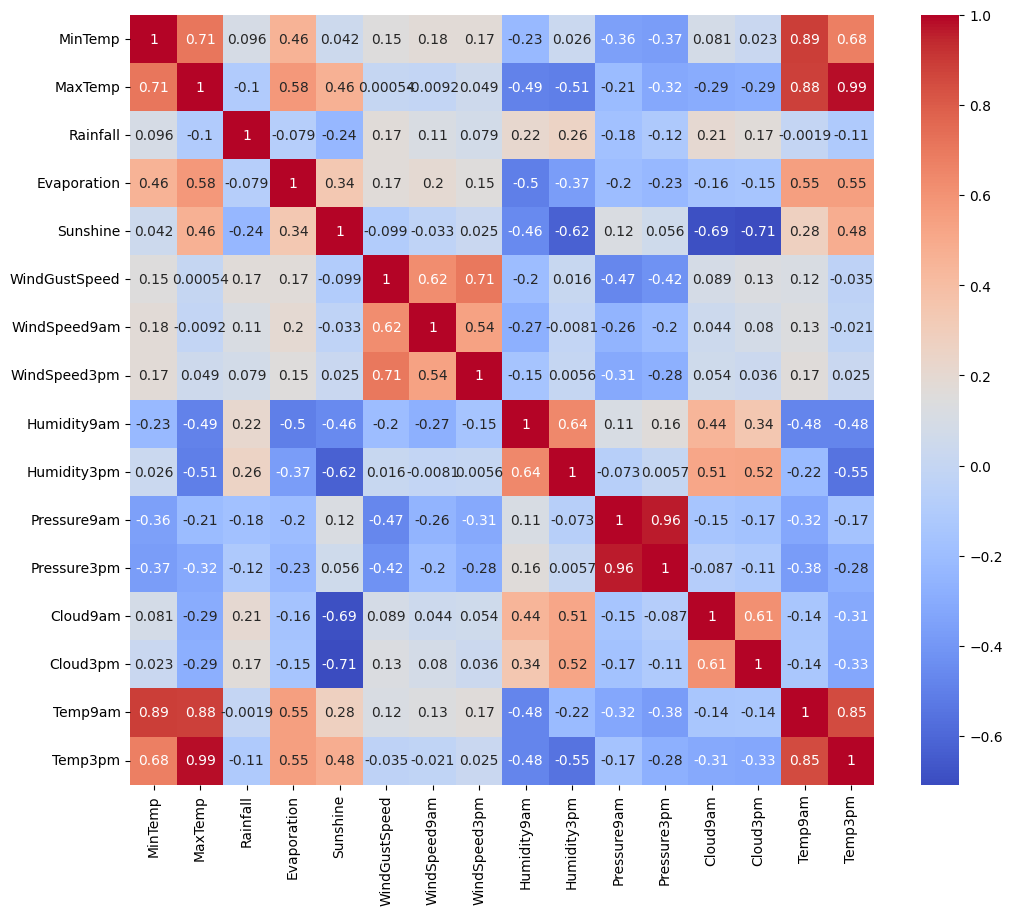

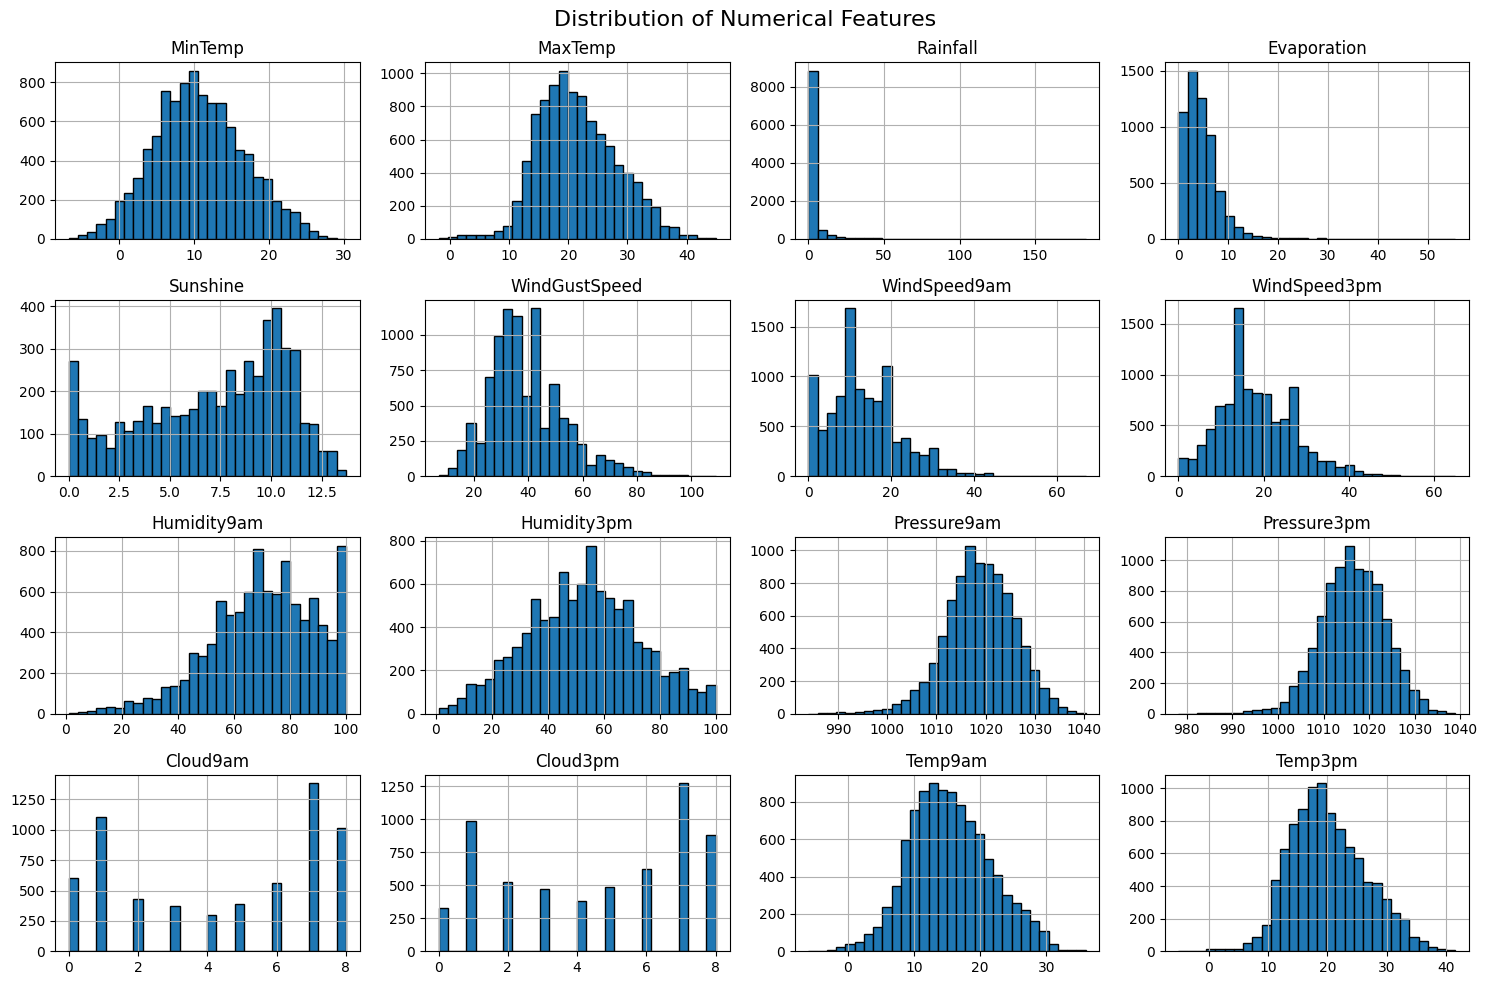

In [59]:
# 2ζ

#Στατιστικά στοιχεία για τα χαρακτηριστικά με αριθμητικές τιμές
display(df.describe())

#Στατιστικά στοιχεία για τα χαρακτηριστικά με μη-αριθμητικές τιμές
display(df.describe(exclude=[np.number]))

#Πόσες null τιμές έχει;
display(df.isnull().sum())

#Correlation Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.show()

#Distribution of features
numerical_cols=df.select_dtypes(include=np.number).columns
df[numerical_cols].hist(bins=30, figsize=(15, 10), color='C0', edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

### 3. Προεπεξεργασία συνόλου δεδομένων

Πρέπει να γίνουν οι παρακάτω ενέργειες:
*   Συνένωση χαρακτηριστικών με υψηλή συσχέτιση
*   Καθαρισμός χαρακτηριστικών με πολλά Null Values
*   Καθαρισμός γραμμών με null τιμές στο RainTomorrow
*   Συμπλήρωση null τιμών
*   Κωδικοποίηση κατηγορικών δεδομένων
*   Διαχωρισμός δεδομένων


💡`Χρησιμοποιήστε το Column Transformer για τη δημιουργία και την εφαρμογή χωριστών μετασχηματιστών για αριθμητικά και κατηγορικά δεδομένα.`




In [60]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

3.α.  Θα χρησιμοποιήσετε όλα τα χαρακτηριστικά του συνόλου δεδομένων για την εκπαίδευση των ταξινομητών ή θα επιλέξετε κάποια από αυτά;  Θα κάνετε κάποια συνένωση κάποιων χαρακτηριστικών για δημιουργία νέων χαρακτηριστικών για το μοντέλο σας;

>Προφανώς δεν είναι όλα τα χαρακτηριστικά χρήσιμα για την εκπαίδευση. Αρχικά κάνουμε συνένωση χαρακτηριστικών με υψηλή συσχέτιση μεταξύ τους:
>*    Temp3pm με MaxTemp -> MaxTemp
>*    Temp9am με MinTemp -> MinTemp
>*    Pressure9am με Pressure3pm -> Pressure
>*    Cloud9am με Cloud3pm -> Cloud
>*    Humidity9am με Humidity3pm -> Humidity


>Θα κάνουμε συσχέτιση των WindGustDir, WindDir9am και WindDir3pm γιατί μετά στο encoding Θα δημιουργηθούν αρκετές στήλες και η κατεύθυνση του αέρα δεν αλλάζει δραματικά μέσα στη μέρα οπότε θα κρατάμε την κατεύθυνση στις 3μμ που είναι πιο κοντά στην επόμενη ημέρα κρατώντας πάντοτε τα δεδομένα και από τις άλλες στήλες όπου υπάρχουν κενά.




In [61]:
#Κρατάμε κυρίως τις τιμές στις 3μμ γιατί είναι πιο κοντά στην επόμενη μέρα
df['MinTemp']=df['MinTemp'].combine_first(df['Temp9am'])
df['MaxTemp']=df['MaxTemp'].combine_first(df['Temp3pm'])
df['Pressure']=df['Pressure3pm'].combine_first(df['Pressure9am'])
df['Cloud']=df['Cloud3pm'].combine_first(df['Cloud9am'])
df['Humidity']=df['Humidity3pm'].combine_first(df['Humidity9am'])
df['WindDir']=df['WindDir3pm'].combine_first(df['WindDir9am'])
df['WindDir']=df['WindDir'].combine_first(df['WindGustDir'])
df=df.drop(columns=['Temp3pm', 'Temp9am', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Humidity3pm', 'Humidity9am', 'WindDir9am', 'WindDir3pm', 'WindGustDir'])


display(df.head())

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,RainToday,RainTomorrow,Pressure,Cloud,Humidity,WindDir
0,2009-03-22,Albury,14.6,30.0,0.0,NaN,NaN,37.0,4.0,19.0,No,No,1012.7,1.0,30.0,NNE
1,2009-04-15,Albury,10.7,21.9,0.0,NaN,NaN,63.0,26.0,31.0,No,No,1009.8,2.0,27.0,W
2,2009-04-21,Albury,5.7,21.4,0.0,NaN,NaN,17.0,6.0,7.0,No,No,1020.9,NaN,39.0,SSE
3,2009-04-24,Albury,10.6,16.2,0.0,NaN,NaN,39.0,7.0,4.0,No,Yes,1002.4,8.0,86.0,NNE
4,2009-05-19,Albury,3.7,19.1,0.0,NaN,NaN,19.0,0.0,11.0,No,No,1019.9,NaN,51.0,SSE


>Στη συνέχεια θα σβήσουμε χαρακτηριστικά που έχουν πολλά null values σε βαθμό που και να τις γεμίσουμε δεν θα έχουμε αξιόπιστο αποτέλεσμα.

> **Θα γίνει στο ερώτημα 3β**

3.β. Υπάρχουν απουσιάζουσες τιμές; Γράψτε κατάλληλο κώδικα ώστε να χειριστείτε αυτές τις τιμές.

In [62]:
display(df.isnull().sum())

,0
Date,0
Location,0
MinTemp,84
MaxTemp,60
Rainfall,219
Evaporation,4337
Sunshine,4825
WindGustSpeed,744
WindSpeed9am,117
WindSpeed3pm,211


>Πρώτο βήμα είναι να σβήσουμε όλες τις γραμμές όπου RainTomorrow έχει Null Value γιατί δεν θα προσφέρει κάτι στην εκπαίδευση του μοντέλου και αν κάνουμε Imputation θα δοθούν λανθασμένα στοιχεία, θα υπάρξει data leakage και χάνεται η ακρίβεια του μοντέλου.

In [63]:
df=df.dropna(subset=['RainTomorrow'])
display(df.isnull().sum())

,0
Date,0
Location,0
MinTemp,33
MaxTemp,14
Rainfall,101
Evaporation,4223
Sunshine,4706
WindGustSpeed,699
WindSpeed9am,98
WindSpeed3pm,194


>Πολλές Null τιμές υπάρχουν ακόμα στα (με φθίνουσα σειρά):
>*    Sunshine
>*    Evaporation
>*    Cloud

>Τις σβήνουμε

,Date,Location,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,RainToday,RainTomorrow,Pressure,Humidity,WindDir
0,2009-03-22,Albury,14.6,30.0,0.0,37.0,4.0,19.0,No,No,1012.7,30.0,NNE
1,2009-04-15,Albury,10.7,21.9,0.0,63.0,26.0,31.0,No,No,1009.8,27.0,W
2,2009-04-21,Albury,5.7,21.4,0.0,17.0,6.0,7.0,No,No,1020.9,39.0,SSE
3,2009-04-24,Albury,10.6,16.2,0.0,39.0,7.0,4.0,No,Yes,1002.4,86.0,NNE
4,2009-05-19,Albury,3.7,19.1,0.0,19.0,0.0,11.0,No,No,1019.9,51.0,SSE


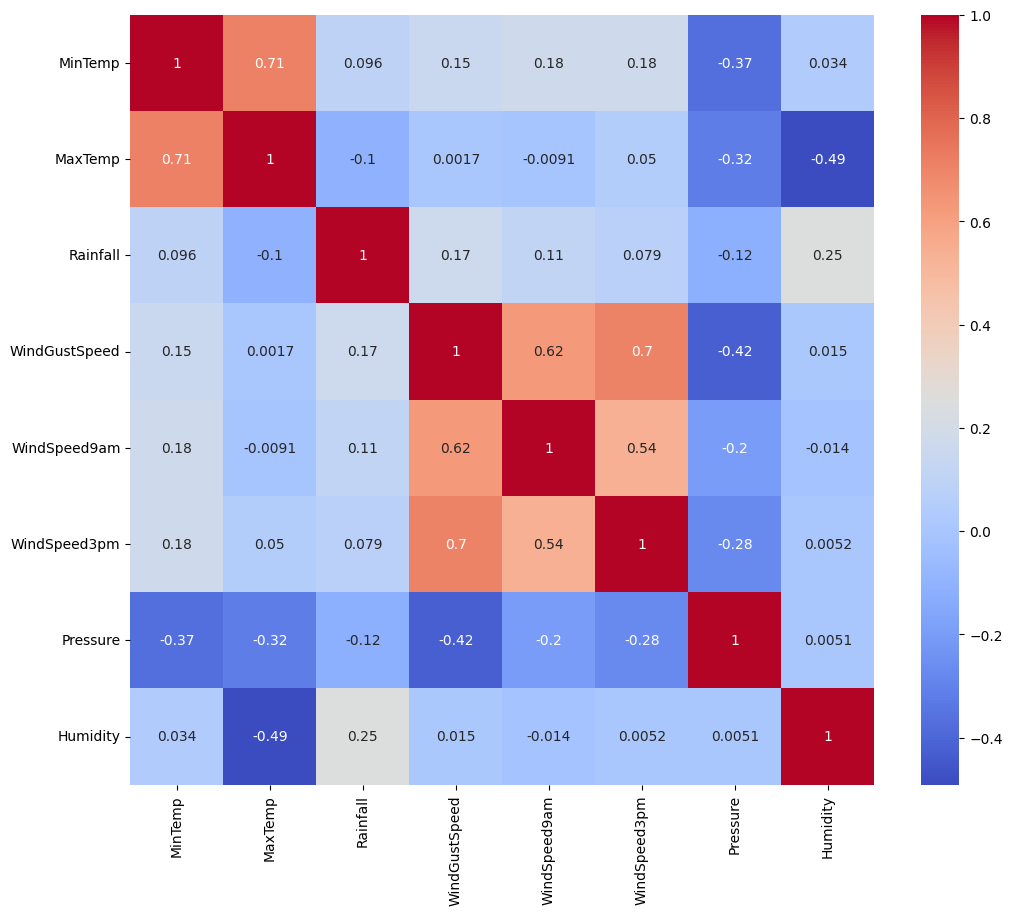

In [64]:
# Drop columns with many missing values
df=df.drop(columns=['Sunshine', 'Evaporation', 'Cloud'])

display(df.head())
#Correlation Heatmap
correlation=df.corr(numeric_only=True)
correlation
plt.figure(figsize=(12,10))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.show()

>Υπάρχουν ακόμα null τιμές και ανάλογα την κατανομή τους θα επιλέξουμε Mean Imputation για όσες έχουν συμμετρική κατανομή και Median Imputation για όσες είναι skewed. Όσο για τα μη αριθμητικά χαρακτηριστικά θα γεμίσουμε τις τιμές με την πιο common τιμή που παίρνουν (αν και πολλά έχουν Null Values και αναλόγως τη συσχέτισή τους με το αποτέλεσμα μπορεί και να διαγραφούν).

>Συγκεκριμένα **Mean Imputation** για τα:
>*   MinTemp, MaxTemp
>*   Humidity
>*   Pressure

>**Median Imputation** για τα:
>*   WindGustSpeed, WindSpeed9am, WindSpeed3pm
>*   Rainfall

>**Most Frequent** για τα:
>*   WindDir
>*   RainToday




In [65]:
#Για τα αριθμητικά δεδομένα
'''
mean_cols=['MinTemp', 'MaxTemp', 'Humidity', 'Pressure']
median_cols=['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Rainfall']
frequent_cols=['WindDir', 'RainToday']
'''
imputer_mean=SimpleImputer(strategy='mean')
imputer_median=SimpleImputer(strategy='median')
imputer_freq=SimpleImputer(strategy='most_frequent')

3.γ. Γράψτε κώδικα για την κατάλληλη μετατροπή των κατηγορικών μεταβλητών ώστε να μπορούν να τους διαχειριστούν οι ταξινομητές που θα χρησιμοποιήσετε.

In [66]:
#RainToday, RainTomorrow YES->1, NO->0
df['RainToday'] = df['RainToday'].map({'Yes': 1, 'No': 0})
df['RainTomorrow'] = df['RainTomorrow'].map({'Yes': 1, 'No': 0})

#Date->Month (Extract the month as a numerical feature)
df['Month'] = pd.to_datetime(df['Date'], errors='coerce').dt.month
df=df.drop(columns=['Date'])

#Location, Wind Directions -> OneHotEncoder
#Θα το χειριστούμε στο 3ε με τον Column Transformer

display(df.head())

,Location,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,RainToday,RainTomorrow,Pressure,Humidity,WindDir,Month
0,Albury,14.6,30.0,0.0,37.0,4.0,19.0,0.0,0,1012.7,30.0,NNE,3
1,Albury,10.7,21.9,0.0,63.0,26.0,31.0,0.0,0,1009.8,27.0,W,4
2,Albury,5.7,21.4,0.0,17.0,6.0,7.0,0.0,0,1020.9,39.0,SSE,4
3,Albury,10.6,16.2,0.0,39.0,7.0,4.0,0.0,1,1002.4,86.0,NNE,4
4,Albury,3.7,19.1,0.0,19.0,0.0,11.0,0.0,0,1019.9,51.0,SSE,5


3.δ. Γράψτε κώδικα για την κλιμάκωση των χαρακτηριστικών, αν την θεωρείτε απαραίτητη

> Η κλιμάκωση είναι απαραίτητη γιατί τα χαρακτηριστικά έχουν διαφορετικές κλίμακες και πολλοί αλγόριθμοι επωφελούνται από την ανακατάταξη των χαρακτηριστικών έτσι ώστε να έχουν ίδιες κλίμακες.

>Αφού το dataset είναι μετεωρολογικό, δηλαδή με συνεχείς μετρήσεις και πιθανότατα όχι τέλεια κανονικές, o StandardScaler είναι προτιμότερος για τους περισσότερους ταξινομητές.

>Ο **MinMaxScaler** είναι ευαίσθητος σε ακραίες τιμές (outliers). Επειδή κλιμακώνει τα δεδομένα σε ένα συγκεκριμένο εύρος (συνήθως [0, 1]), ένα outlier μπορεί να συμπιέσει τα υπόλοιπα δεδομένα σε ένα πολύ μικρό εύρος, καθιστώντας τα λιγότερο διακριτά για τον ταξινομητή. Ο StandardScaler, αντίθετα, κλιμακώνει τα δεδομένα με βάση τη μέση τιμή και την τυπική απόκλιση, καθιστώντας τον λιγότερο ευαίσθητο σε outliers.

>Ο **StandardScaler** διατηρεί την πληροφορία σχετικά με την κατανομή των δεδομένων και τις σχετικές αποστάσεις μεταξύ των σημείων, κάτι που μπορεί να χαθεί με τον MinMaxScaler αν υπάρχουν outliers (ακραίες τιμές).


In [67]:
#Θα υλοποιηθεί στο επόμενο ερώτημα από τον column transformer
numerical_scaler=StandardScaler()
categorical_scaler=OneHotEncoder(handle_unknown='ignore', sparse_output=False)

3.ε. Εκτελέστε όλα τα προηγούμενα βήμα προεκπαίδευσης (χρήση μετασχηματιστών) ώστε να είναι "καθαρό" το αρχικό σύνολο για να χρησιμοποιηθεί για την εκπαίδευση των ταξινομητών.

>Θα επιλέξουμε **mean** για όλα τα αριθμητικά δεδομένα

In [68]:
numerical_features=['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity', 'Pressure', 'Month', 'RainToday']
categorical_features=['Location', 'WindDir']

numerical_transformer=Pipeline(steps=[
    ('imputer', imputer_mean),
    ('scaler', numerical_scaler)
])

categorical_transformer=Pipeline(steps=[
    ('imputer', imputer_freq),
    ('scaler', categorical_scaler)
])

preprocessor=ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

3.στ. Αφού έχετε "καθαρίσει" το αρχικό σύνολο εκπαίδευσης, γράψτε τον κατάλληλο κώδικα ώστε από το αρχικό σύνολο εκπαίδευσης να δημιουργήσετε τα σύνολα Χ και y.

💡 `Η στήλη 'RainTomorrow' είναι η τιμή που θέλουμε να προβλέψει ο ταξινομητής μας.`



In [69]:
x=df.drop('RainTomorrow', axis=1)
y=df['RainTomorrow']

3.ζ. Διαχωρίστε το σύνολο δεδομένων σε σύνολο εκπαίδευσης (train set) και σε σύνολο επικύρωσης (validation set) (ο διαχωρισμός να είναι train set 70% και validation set 30%).


In [70]:
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.3, random_state=42)

### 4. Εκπαίδευση μοντέλου με default τιμές στις παραμέτρους των ταξινομητών

Θα εκπαιδεύσουμε τους ακόλουθους ταξινομητές με το σύνολο εκπαίδευσης των δεδομένων μας:
1. Naive Bayes
2. KNeighborsClassifier
3. LogisticRegression
4. MLP με ένα κρυφό επίπεδο
5. SVC
6. Decision Tree
7. Random Forest


In [71]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, roc_auc_score

 4.α. Εκπαιδεύστε (fit)  και τους  7 ταξινομητές που προαναφέρθηκαν (εμφανίστε τα δείγματα από το train set μαζί με την ετικέτα τους στην είσοδο του κάθε ταξινομητή), χρησιμοποιώντας τις default τιμές για όλες τις παραμέτρους τους.

In [72]:
# Initialize the models
models={
    'GaussianNB': GaussianNB(),
    'KNN': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(),
    'MLP': MLPClassifier(),
    'SVC': SVC(),
    'DecisionTree': DecisionTreeClassifier(),
    'RandomForest': RandomForestClassifier()
}

trained_models={}
for name, classifier in models.items():
    print(f"Training {name}...\n")
    model=Pipeline(steps=[('preprocessor', preprocessor), ('classifier', classifier)])
    print(f"Train Set Data\n")
    print(x_train.head()) #Προφανώς head γιατί δεν θα χωρέσουν όλα τα δείγματα
    print("\n")
    print(f"Train Set Targets\n")
    print(y_train.head())
    print("\n")
    model.fit(x_train, y_train)
    trained_models[name]=model
    print(f"{name} training complete.\n")
print("\nAll models trained.")

Training GaussianNB...

Train Set Data

          Location  MinTemp  MaxTemp  Rainfall  WindGustSpeed  WindSpeed9am  \
9661        Darwin     21.9     34.8       0.0           44.0           7.0   
3617   Tuggeranong     -4.4      8.8       0.0           35.0           0.0   
6880  MountGambier      9.1     17.0       0.0           46.0          24.0   
9001        Hobart      9.0     17.6       2.2           52.0           6.0   
8039    PearceRAAF     18.7     25.9       2.4           46.0           9.0   

      WindSpeed3pm  RainToday  Pressure  Humidity WindDir  Month  
9661          28.0        0.0    1011.1      49.0     NNW      9  
3617          17.0        0.0    1017.9      48.0      NW      8  
6880          22.0        0.0    1006.2      60.0     NNW      7  
9001          22.0        1.0    1019.5      60.0      NE     10  
8039          30.0        1.0    1009.1      54.0      SW      3  


Train Set Targets

9661    0
3617    0
6880    1
9001    0
8039    0
Name: RainTo

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP training complete.

Training SVC...

Train Set Data

          Location  MinTemp  MaxTemp  Rainfall  WindGustSpeed  WindSpeed9am  \
9661        Darwin     21.9     34.8       0.0           44.0           7.0   
3617   Tuggeranong     -4.4      8.8       0.0           35.0           0.0   
6880  MountGambier      9.1     17.0       0.0           46.0          24.0   
9001        Hobart      9.0     17.6       2.2           52.0           6.0   
8039    PearceRAAF     18.7     25.9       2.4           46.0           9.0   

      WindSpeed3pm  RainToday  Pressure  Humidity WindDir  Month  
9661          28.0        0.0    1011.1      49.0     NNW      9  
3617          17.0        0.0    1017.9      48.0      NW      8  
6880          22.0        0.0    1006.2      60.0     NNW      7  
9001          22.0        1.0    1019.5      60.0      NE     10  
8039          30.0        1.0    1009.1      54.0      SW      3  


Train Set Targets

9661    0
3617    0
6880    1
9001    0
8039 

4.β. Εφαρμόστε στα εκπαιδευμένα μοντέλα από το validation set μόνο τα δείγματα χωρίς την ετικέτα τους (predict).


In [73]:
predictions={}
for name, model in trained_models.items():
  print(f"Making predictions with {name}...")
  y_pred=model.predict(x_test)
  predictions[name]=y_pred
  print(f"{name} predictions complete.\n")
print("All predictions made.")

Making predictions with GaussianNB...
GaussianNB predictions complete.

Making predictions with KNN...
KNN predictions complete.

Making predictions with LogisticRegression...
LogisticRegression predictions complete.

Making predictions with MLP...
MLP predictions complete.

Making predictions with SVC...
SVC predictions complete.

Making predictions with DecisionTree...
DecisionTree predictions complete.

Making predictions with RandomForest...
RandomForest predictions complete.

All predictions made.



4.γ. Συγκρίνετε την έξοδο του κάθε μοντέλου σε σχέση με τις αντίστοιχες ετικέτες του validation set και αξιολογήστε την επιδοσή τους χρησιμοποιώντας το F1 score.


In [74]:
for name, model in trained_models.items():
    y_pred=predictions[name]
    print(f"Results for {name}")
    print(y_test[:10]) #Προφανώς δεν χωράει όλο το validation set οπότε κοιτάμε τις πρώτες 10 γραμμ
    print(y_pred[:10])
    print(f"F1 Score {name}: {f1_score(y_test, y_pred)}\n")

Results for GaussianNB
537     0
881     0
1171    1
2320    1
4128    1
1756    0
5137    0
4319    0
6824    0
7762    0
Name: RainTomorrow, dtype: int64
[0 0 1 1 0 0 0 1 1 1]
F1 Score GaussianNB: 0.46272028920018077

Results for KNN
537     0
881     0
1171    1
2320    1
4128    1
1756    0
5137    0
4319    0
6824    0
7762    0
Name: RainTomorrow, dtype: int64
[0 0 0 0 0 0 0 0 0 1]
F1 Score KNN: 0.5616438356164384

Results for LogisticRegression
537     0
881     0
1171    1
2320    1
4128    1
1756    0
5137    0
4319    0
6824    0
7762    0
Name: RainTomorrow, dtype: int64
[0 0 0 0 1 0 0 0 0 0]
F1 Score LogisticRegression: 0.583756345177665

Results for MLP
537     0
881     0
1171    1
2320    1
4128    1
1756    0
5137    0
4319    0
6824    0
7762    0
Name: RainTomorrow, dtype: int64
[0 0 0 0 0 0 0 0 0 0]
F1 Score MLP: 0.5781618224666143

Results for SVC
537     0
881     0
1171    1
2320    1
4128    1
1756    0
5137    0
4319    0
6824    0
7762    0
Name: RainTomorrow, 

4.δ.  Αξιολογήστε συνολικά την επίδοση των μοντέλων χρησιμοποιώντας κάποιο γράφημα (π.χ. ιστόγραμμα, bar plot) και σχολιάστε ποιο μοντέλο είχε την καλύτερη επίδοση.


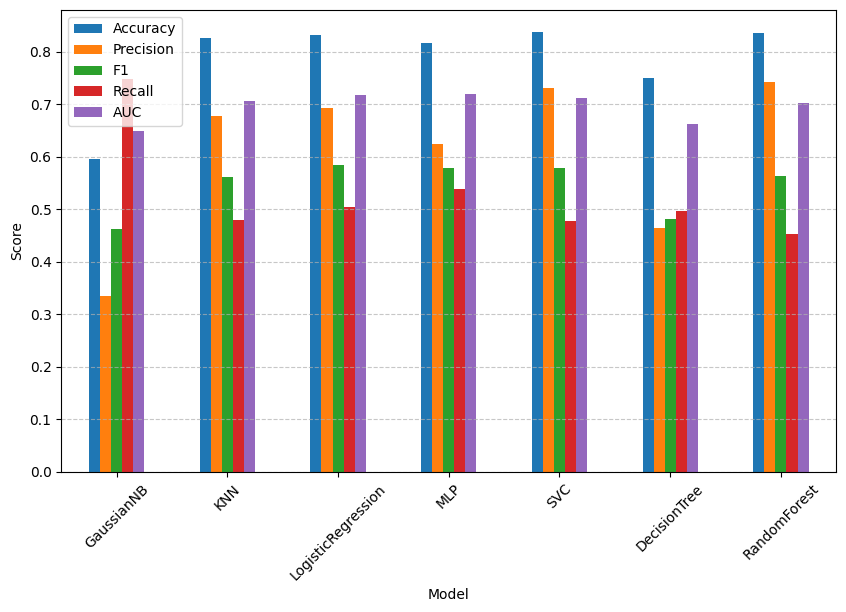

In [75]:
results=[]
for name, model in trained_models.items():
    y_pred=predictions[name]
    results.append({
        'Model': name,
        'Prediction': y_pred,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_pred)
    })
results_df=pd.DataFrame(results)

results_df.set_index('Model').plot(kind='bar', figsize=(10,6))
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


>Βάσει του F1 Score (ισορροπία μεταξύ Precision και Recall) που ζητήθηκε παραπάνω βλέπουμε ότι στους αριθμούς **καλύτερη επίδοση έχει ο MLP** και **παρόμοια F1 Scores έχουν και οι SVC, RandomForest και Logistic Regression.**

>Όλα τα μοντέλα πλην του GaussianNB έχουν καλό Accuracy (κοντά στο 0.8) που σημαίνει ότι γίνονται σωστές προβλέψεις.

>Στο **Precision** υστερεί το DecisionTree και το GaussianNB με όλα τα υπόλοιπα μοντέλα να έχουν Precision κοντά στο 0.7 πλην του MLP που είναι κοντά στο 0.6. Άρα αν θέλουμε μεγαλύτερο Precision δεν θα προτιμήσουμε MLP και GaussianNB.

>Στο **Recall** (ανίχνευση θετικών παραδειγμάτων) είναι η μόνη μετρική που ο NaiveBayes είναι καλύτερος από όλους κατά έναν μεγάλο βαθμό. Αν δηλαδή θέλουμε να μην χάνουμε τις μέρες με βροχή θα ήταν καλό να χρησιμοποιήσουμε NaiveBayes αλλά με τις άλλες μετρικές να είναι πολύ χαμηλές δεν θα το προτιμούσαμε. Όλοι οι υπόλοιποι ταξινομητές είναι στα ίδια επίπεδα στο Recall.

>Συνεπώς, σε γενικές γραμμές βλέπουμε πως ο **MLP είναι προτιμότερος** με το υψηλότερο Recall (εκτός του GaussianNB) και αυτός με το μεγαλύτερο F1 Score, θυσιάζοντας λίγο το Precision.

### 5. Βελτιστοποίηση μοντέλων με εύρεση καλύτερων υπερπαραμέτρων των ταξινομητών

5.α. Για τους 7 ταξινομητές βελτιστοποιήστε την επίδοσή τους χρησιμοποιώντας αναζήτηση πλέγματος με διασταυρούμενη επικύρωση (k-fold 5)  με σκοπό την εύρεση των βέλτιστων υπερπαραμέτρων.

In [76]:
from sklearn.model_selection import GridSearchCV
import warnings
from sklearn.exceptions import FitFailedWarning

search_space={
    'GaussianNB':{
        'classifier__var_smoothing': [1e-9, 1e-8, 1e-7]
    },
    'KNN':{
      'classifier__n_neighbors': [1, 3, 5],
      'classifier__metric': ['euclidean','manhattan']
    },
    'LogisticRegression':{
        'classifier__penalty': ['l1', 'l2'],
        'classifier__C': np.logspace(-2,2,10)
    },
    'MLP':{
        'classifier__hidden_layer_sizes': [(50,), (100,), (50, 50)],
        'classifier__activation': ['tanh', 'relu'],
        'classifier__alpha': [0.0001, 0.001, 0.01]
    },
    'SVC':{
        'classifier__C': [0.1, 1, 10],
        'classifier__gamma': [1e-3, 1e-4],
        'classifier__kernel': ['rbf', 'linear']
    },
    'DecisionTree':{
        'classifier__max_depth': [None, 10, 20, 30],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__criterion': ['gini', 'entropy']
    },
    'RandomForest':{
        'classifier__n_estimators': range(100,500,50),
        'classifier__max_depth': range(5,10,1)
    }
}

best_models={}

for name, classifier in models.items():
    print(f"Grid Searching for {name}...\n")
    pipe=Pipeline(steps=[('preprocessor', preprocessor), ('classifier', classifier)])
    grid_search=GridSearchCV(pipe, search_space[name], cv=5, scoring='f1', n_jobs=-1)
    grid_search.fit(x_train, y_train)
    best_models[name] = grid_search.best_estimator_
    print(f"Best parameters for {name}: {grid_search.best_params_}\n")
    warnings.filterwarnings("ignore")

Grid Searching for GaussianNB...

Best parameters for GaussianNB: {'classifier__var_smoothing': 1e-09}

Grid Searching for KNN...

Best parameters for KNN: {'classifier__metric': 'euclidean', 'classifier__n_neighbors': 3}

Grid Searching for LogisticRegression...

Best parameters for LogisticRegression: {'classifier__C': np.float64(0.5994842503189409), 'classifier__penalty': 'l2'}

Grid Searching for MLP...

Best parameters for MLP: {'classifier__activation': 'tanh', 'classifier__alpha': 0.0001, 'classifier__hidden_layer_sizes': (50,)}

Grid Searching for SVC...

Best parameters for SVC: {'classifier__C': 1, 'classifier__gamma': 0.001, 'classifier__kernel': 'linear'}

Grid Searching for DecisionTree...

Best parameters for DecisionTree: {'classifier__criterion': 'gini', 'classifier__max_depth': 10, 'classifier__min_samples_split': 2}

Grid Searching for RandomForest...

Best parameters for RandomForest: {'classifier__max_depth': 9, 'classifier__n_estimators': 200}



5.β. Εφαρμόστε στα εκπαιδευμένα μοντέλα από το validation set μόνο τα δείγματα χωρίς την ετικέτα τους (predict).


In [77]:
predictions_val={}

for name, model in best_models.items():
    y_pred=model.predict(x_test)
    predictions_val[name]=y_pred
    print(f"{name} {y_pred[:10]}")

GaussianNB [0 0 1 1 0 0 0 1 1 1]
KNN [0 1 0 0 0 0 0 0 1 1]
LogisticRegression [0 0 0 0 1 0 0 0 0 0]
MLP [0 0 0 0 0 0 0 0 0 1]
SVC [0 0 0 0 1 0 0 0 0 0]
DecisionTree [0 0 0 0 1 0 0 0 0 0]
RandomForest [0 0 0 0 1 0 0 0 0 0]



5.γ. Συγκρίνετε την έξοδο του κάθε μοντέλου σε σχέση με τις αντίστοιχες ετικέτες του validation set και αξιολογήστε την επιδοσή τους χρησιμοποιώντας το F1 score.


In [78]:
f1_scores={}

for name, y_pred in predictions_val.items():
    f1=f1_score(y_test, y_pred)
    f1_scores[name]=f1
    print(f"{name}: F1 Score = {f1}")

GaussianNB: F1 Score = 0.46272028920018077
KNN: F1 Score = 0.5416666666666666
LogisticRegression: F1 Score = 0.5835453774385072
MLP: F1 Score = 0.6146496815286624
SVC: F1 Score = 0.579225352112676
DecisionTree: F1 Score = 0.5098360655737705
RandomForest: F1 Score = 0.4900398406374502


>Ξανά **ο MLP είναι ο ταξινομητής με την μεγαλύτερη επίδοση** και **ο GaussianNB με την χειρότερη.** Παρατηρούμε ότι τα F1 Score είναι υψηλότερα από προηγουμένως ιδίως στον MLP

5.δ.  Αξιολογήστε συνολικά την επίδοση των μοντέλων χρησιμοποιώντας κάποιο γράφημα (π.χ. ιστόγραμμα, bar plot) και σχολιάστε ποιο μοντέλο είχε την καλύτερη επίδοση.


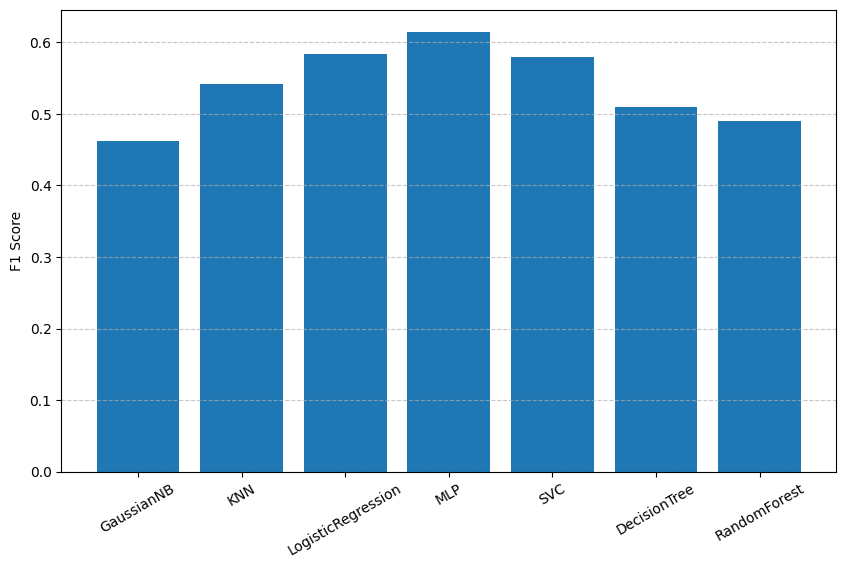

In [79]:
plt.figure(figsize=(10, 6))
plt.bar(f1_scores.keys(), f1_scores.values())
plt.ylabel("F1 Score")
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

>Αν και όλα τα μοντέλα έχουν παρόμοιες τιμές F1 Score, ο **MLP υπερτερεί**. Στη συνέχεια είναι τα Logisticregression και SVC. Έπειτα, τα DecisionTree και RandomForest αφήνοντας τελευταίο το GaussianNB.

### 6. Έλεγχος επίδοσης βελτιστοποιημένων μοντέλων

6.α. Εφαρμόστε τους επτά βελτιστοποιημένους ταξινομητές στα δείγματα του [test set](https://drive.google.com/file/d/1F5WJ4S0A6PDRQ_a8gCXyJIu4rbZ7amWX/view?usp=sharing) (χωρίς τις ετικέτες του) για την παραγωγή προβλέψεων (predict).

In [80]:
test_df=pd.read_csv("test.csv")
display(test_df.isnull().sum())

,0
Date,0
Location,0
MinTemp,52
MaxTemp,46
Rainfall,125
Evaporation,1836
Sunshine,1857
WindGustDir,330
WindGustSpeed,327
WindDir9am,253


>Επειδή βλέπουμε ότι το test set πάλι έχει αρκετά κενά, θα κάνουμε την ίδια διαδικασία που ακολουθήσαμε στα ερωτήματα **3α-3ε**

In [81]:
#Κρατάμε κυρίως τις τιμές στις 3μμ γιατί είναι πιο κοντά στην επόμενη μέρα
test_df['MinTemp']=test_df['MinTemp'].combine_first(test_df['Temp9am'])
test_df['MaxTemp']=test_df['MaxTemp'].combine_first(test_df['Temp3pm'])
test_df['Pressure']=test_df['Pressure3pm'].combine_first(test_df['Pressure9am'])
test_df['Cloud']=test_df['Cloud3pm'].combine_first(test_df['Cloud9am'])
test_df['Humidity']=test_df['Humidity3pm'].combine_first(test_df['Humidity9am'])
test_df['WindDir']=test_df['WindDir3pm'].combine_first(test_df['WindDir9am'])
test_df['WindDir']=test_df['WindDir'].combine_first(test_df['WindGustDir'])
test_df=test_df.drop(columns=['Temp3pm', 'Temp9am', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Humidity3pm', 'Humidity9am', 'WindDir9am', 'WindDir3pm', 'WindGustDir'])

#RainToday, RainTomorrow YES->1, NO->0
test_df['RainToday']=test_df['RainToday'].map({'Yes': 1, 'No': 0})
test_df['RainTomorrow']=test_df['RainTomorrow'].map({'Yes': 1, 'No': 0})

#Date->Month (Extract the month as a numerical feature)
test_df['Month']=pd.to_datetime(test_df['Date'], errors='coerce').dt.month
test_df=test_df.drop(columns=['Date'])

display(test_df.head())

#Drop rows with Null Values of RainTomorrow
test_df=test_df.dropna(subset=['RainTomorrow'])
display(test_df.isnull().sum())

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,RainToday,RainTomorrow,Pressure,Cloud,Humidity,WindDir,Month
0,Albury,4.7,16.6,0.2,NaN,NaN,22.0,6.0,11.0,0.0,0.0,1028.1,1.0,56.0,W,8
1,Albury,2.2,16.8,0.0,NaN,NaN,19.0,0.0,11.0,0.0,0.0,1030.1,1.0,56.0,ESE,8
2,Albury,0.2,13.6,0.0,NaN,NaN,30.0,7.0,19.0,0.0,0.0,1020.5,1.0,50.0,W,8
3,Albury,3.4,18.2,0.0,NaN,NaN,26.0,0.0,9.0,0.0,0.0,1024.2,3.0,51.0,N,8
4,Albury,5.5,20.5,0.0,NaN,NaN,22.0,0.0,7.0,0.0,0.0,1027.4,1.0,60.0,ESE,9


,0
Location,0
MinTemp,9
MaxTemp,3
Rainfall,57
Evaporation,1765
Sunshine,1793
WindGustSpeed,294
WindSpeed9am,26
WindSpeed3pm,69
RainToday,57


In [82]:
# Drop columns with many Null Values - Ensure these are the same columns dropped from the training data
test_df=test_df.drop(columns=['Sunshine', 'Evaporation', 'Cloud'])

display(test_df.head())

,Location,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,RainToday,RainTomorrow,Pressure,Humidity,WindDir,Month
0,Albury,4.7,16.6,0.2,22.0,6.0,11.0,0.0,0.0,1028.1,56.0,W,8
1,Albury,2.2,16.8,0.0,19.0,0.0,11.0,0.0,0.0,1030.1,56.0,ESE,8
2,Albury,0.2,13.6,0.0,30.0,7.0,19.0,0.0,0.0,1020.5,50.0,W,8
3,Albury,3.4,18.2,0.0,26.0,0.0,9.0,0.0,0.0,1024.2,51.0,N,8
4,Albury,5.5,20.5,0.0,22.0,0.0,7.0,0.0,0.0,1027.4,60.0,ESE,9


In [83]:
x_test=test_df.drop('RainTomorrow', axis=1)
y_test=test_df['RainTomorrow']

test_predictions = {}
for name, model in best_models.items():
    y_pred = model.predict(x_test)
    test_predictions[name]=y_pred
    print(f"{name} predictions complete.")

GaussianNB predictions complete.
KNN predictions complete.
LogisticRegression predictions complete.
MLP predictions complete.
SVC predictions complete.
DecisionTree predictions complete.
RandomForest predictions complete.


6.β. Συγκρίνετε την έξοδο του κάθε ταξινομητή σε σχέση με τις αντίστοιχες ετικέτες του [test set](https://drive.google.com/file/d/1F5WJ4S0A6PDRQ_a8gCXyJIu4rbZ7amWX/view?usp=sharing) και αξιολογήστε την επιδοσή τους χρησιμοποιώντας το Precision και το recall.



In [84]:
precision_scores={}
recall_scores={}

for name, y_pred in test_predictions.items():
    precision=precision_score(y_test, y_pred)
    recall=recall_score(y_test, y_pred)
    precision_scores[name]=precision
    recall_scores[name]=recall
    print(f"{name} -> Precision: {precision}, Recall: {recall}")

GaussianNB -> Precision: 0.3357458785685565, Recall: 0.7833020637898687
KNN -> Precision: 0.6486146095717884, Recall: 0.4831144465290807
LogisticRegression -> Precision: 0.7427821522309711, Recall: 0.5309568480300187
MLP -> Precision: 0.7168742921857305, Recall: 0.5938086303939962
SVC -> Precision: 0.7567954220314735, Recall: 0.49624765478424016
DecisionTree -> Precision: 0.6181818181818182, Recall: 0.44652908067542213
RandomForest -> Precision: 0.8195329087048833, Recall: 0.3621013133208255


>Το μοντέλο **RandomForest** έχει το **υψηλότερο Precision**.

>Το **μοντέλο GaussianNB** έχει το **υψηλότερο Recall**.

>Η επιλογή του μοντέλου με την 'καλύτερη συνολική επίδοση' εξαρτάται από την επιθυμητή ισορροπία μεταξύ αυτών των δύο μετρικών.

6.γ. Αξιολογήστε συνολικά την επίδοση των βελτιστοποιημένων μοντέλων στο test set, χρησιμοποιώντας κάποιο γράφημα (π.χ. ιστόγραμμα, bar plot) και σχολιάστε ποιο μοντέλο είχε την καλύτερη επίδοση.

In [85]:
f1_scores={}
accuracy_scores={}

for name, y_pred in test_predictions.items():
    f1=f1_score(y_test, y_pred)
    acc=accuracy_score(y_test, y_pred)
    f1_scores[name]=f1
    accuracy_scores[name]=acc

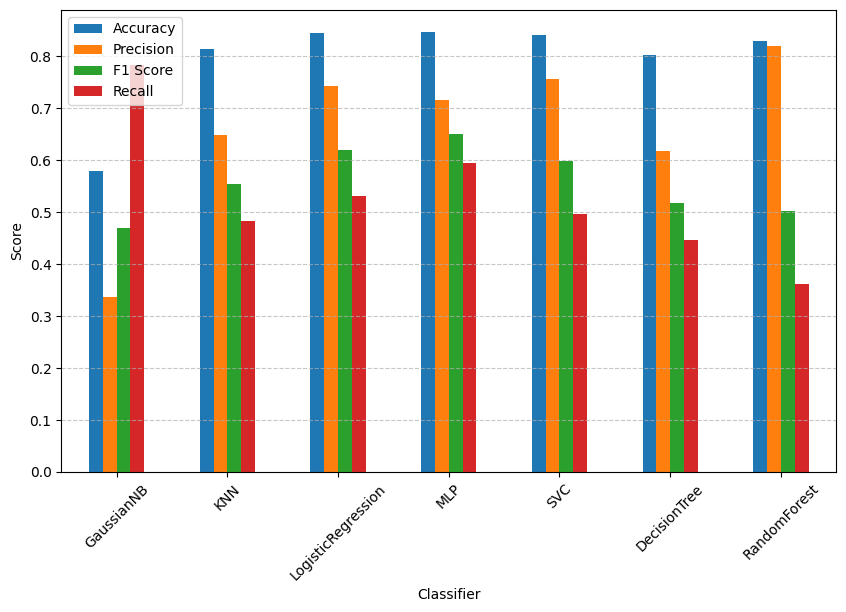

In [86]:
results_df=pd.DataFrame({
    'Classifier': precision_scores.keys(),
    'Accuracy': accuracy_scores.values(),
    'Precision': precision_scores.values(),
    'F1 Score': f1_scores.values(),
    'Recall': recall_scores.values(),
})

results_df.set_index('Classifier').plot(kind='bar', figsize=(10,6))
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

>Για την πρόβλεψη βροχής, τόσο το Precision όσο και το Recall είναι σημαντικά.
>- Ένα **υψηλό Precision** σημαίνει ότι όταν το μοντέλο προβλέπει βροχή, είναι πιθανό να βρέξει **(λιγότεροι ψευδώς θετικοί συναγερμοί)**.
>- Ένα **υψηλό Recall** σημαίνει ότι το μοντέλο εντοπίζει ένα μεγάλο ποσοστό των ημερών που όντως βρέχει **(λιγότεροι ψευδώς αρνητικοί)**.
Η επιλογή του 'καλύτερου' μοντέλου εξαρτάται από το ποια από αυτές τις μετρικές είναι πιο κρίσιμη.

>Για παράδειγμα, αν θέλουμε να αποφύγουμε ψευδείς συναγερμούς (π.χ. για προγραμματισμό εξωτερικών εργασιών), θα δίναμε βάρος στο Precision.
Αν θέλουμε να βεβαιωθούμε ότι δεν θα χάσουμε μέρες με βροχή (π.χ. για γεωργικές εφαρμογές), θα δίναμε βάρος στο Recall.

>Όπως προηγουμένως βλέπουμε το ίδιο μοτίβο. Οι **KNN, LogisticRegression, MLP, SVC και DecisionTree** έχουν παρόμοιες μετρικές, ο **GaussianNB έχει πολύ υψηλό Recall** σε αντίθεση με τα υπόλοιπα μοντέλα με όλες τις άλλες μετρικές του χαμηλές και ο **RandomForest έχει υψηλό Precision** αλλά υστερεί στις άλλες μετρικές.

Απαντήστε στις ακόλουθες ερωτήσεις:

1. Ποιο μοντέλο παρουσιάζει την καλύτερη συνολική ισορροπία μεταξύ precision και recall; Πού πιστεύετε ότι οφείλεται η επίδοση αυτή;
  >Το μοντέλο MLP έχει υψηλότερη ισορροπία μεταξύ precision και recall γιατί έχει υψηλότερα F1 Score.

    >Αυτή η επίδοση μπορεί να οφείλεται στο ότι το MLP μπορεί να συλλάβει μη γραμμικές σχέσεις στα δεδομένα, κάτι που είναι συχνό στα μετεωρολογικά φαινόμενα. Η βελτιστοποίηση των υπερπαραμέτρων (όπως το `hidden_layer_sizes` και η `activation`) βοήθησε περαιτέρω στην προσαρμογή του μοντέλου στην πολυπλοκότητα του προβλήματος.

2. Ποιο μοντέλο εμφανίζει τη μεγαλύτερη διακύμανση στις επιδόσεις του, μεταξύ διαφορετικών folds ή runs; Πώς θα μπορούσατε να ερμηνεύσετε αυτή τη συμπεριφορά;
  >Μεταξύ των folds δεν ελέγχουμε τις επιδόσεις του κάθε μοντέλου, αλλά τα DecisionTree και KNN θεωρητικά επηρεάζονται από το κάθε fold γιατί σε κάθε fold αλλάζει η δομή των δέντρων και η σύνθεση των γειτόνων που σημαίνει ότι αλλάζουν και οι προβλέψεις άρα θα υπάρχει και διακύμανση στις επιδόσεις. Πρακτικά θα μπορούσαμε μόνο να κρίνουμε ποιό μοντέλο είχε μεγαλύτερη διακύμανση μεταξύ training και testing.

    >Τα MLP και Logistic Regression εμφανίζουν πολύ μικρή διακύμανση καθώς στο testing αυξάνουν το F1 Score τους με τα υπόλοιπα μοντέλα να μένουν στα ίδια επίπεδα. Το DecisionTree βέβαια εμφανίζει μακράν τη μεγαλύτερη διακύμανση με το Precision και το Accuracy να εμφανίζουν ραγδαίες αυξήσεις με το F1 Score όμως να παραμένει στις ίδιες τιμές.

    >Αυτό οφείλεται και στα ίδια τα μοντέλα και πως λειτουργούν όπως εξήγησα παραπάνω, αλλά και στο ότι έχει επέλθει cross validation μεταξύ training και testing.

3. Ποιο μοντέλο φαίνεται να υπερεκπαιδεύεται (overfitting) ή να υποεκπαιδεύεται (underfitting) με βάση τη σύγκριση των train και test scores; Ποιες τεχνικές θα μπορούσαν να χρησιμοποιηθούν για να αντιμετωπιστεί αυτό;
  >- Overfitting παρατηρείται στα μοντέλα DecisionTree και RandomForest αν συγκρίνει κανείς τα bar plots των μετρικών στο train set και μετά στο test set, όπου παρατηρείται ραγδαία αύξηση των μετρικών Accuracy και Precision να συνοδεύεται από μία μείωση στο Recall. Το F1 Score του RandomForest μειώνεται, ενώ του DecisionTree μένει στα ίδια επίπεδα. Αυτό μας δείχνει ότι τα μοντέλα αυτά (και κυρίως το RandomForest που μειώνεται το F1 του) είναι σε ένα μικρό βαθμό υπερεκπαιδευμένα στα δεδομένα εκπαίδευσης που δεν μπορούν να κάνουν σωστές προβλέψεις σε νέα δεδομένα.
  >- Underfitting παρατηρείται στο GaussianNB όπου βλέπουμε τόσο στο train όσο και στο test set να υπάρχουν χαμηλές μετρικές Precision, Accuracy και F1 Score χωρίς καμία αλλαγή από το ένα set στο άλλο.
  >- Τρόποι αντιμετώπισης του overfitting είναι να έχουμε περισσότερα δεδομένα εκπαίδευσης ή να περιορίσουμε την εκπαίδευση των μοντέλων αυτών είτε με περιορισμό παραμέτρων (π.χ. `max depth` για DecisionTree) είτε με Early Stopping. Ενώ για το Underfitting, δεν μπορούμε να βοηθήσουμε κάπως την GaussianNB να αντιληφθεί πιο περίπλοκες σχέσεις, συνεπώς απλά επιλέγουμε άλλο μοντέλο ανάλογα το dataset το οποίο έχουμε να διαχειριστούμε.


4. Ποια κατηγορία παρουσιάζει τα περισσότερα σφάλματα ταξινόμησης και γιατί; Αναλύστε τα αποτελέσματα του confusion matrix από το καλύτερο μοντέλο σας και σχολιάστε πιθανούς λόγους για τα σφάλματα.
  >TP=633, TN=3152, FP=250, FN=433
    >Συνεπώς μεγαλύτερα σφάλματα βλέπουμε στα False Negative (δηλαδή το μοντέλο να προβλέπει ότι δεν θα βρέξει, ενώ έβρεξε την επόμενη μέρα)

    >Αυτό μπορεί να οφείλεται σε ανισορροπία στα δεδομένα (πολλά RainTommorow=0), στην ελλιπή πληροφόρηση (πολλά null values στο Sunshine, cloud, Evaporation που σβήσαμε), στη μη γραμμικότητα των μετεωρολογικών δεδομένων, αλλά και στο Imputation (άλλες κατηγορίες ήθελαν mean, άλλες median αλλά κάναμε μόνο mean) που μπορεί να μην αντιστοιχεί με τα πραγματικά δεδομένα και να γίνονται παρανοήσεις.

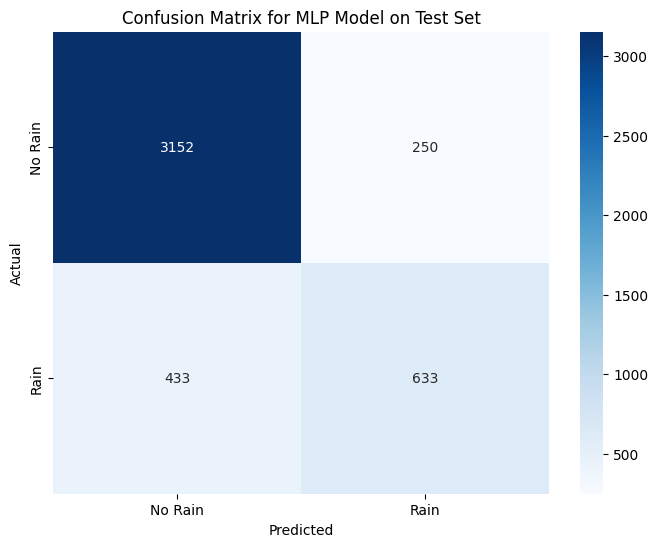

In [87]:
from sklearn.metrics import confusion_matrix
y_pred_mlp=test_predictions['MLP']
cm=confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Rain', 'Rain'], yticklabels=['No Rain', 'Rain'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for MLP Model on Test Set')
plt.show()